# Reinforcement Learning Lab: Bootstrapping Techniques

This notebook implements **bootstrapping-based reinforcement learning algorithms**:

- TD(0) Prediction
- SARSA (On-policy TD Control)
- Q-Learning (Off-policy TD Control)
- N-step TD Control

These methods are evaluated on two environments:

1. **GridWorld** (custom 5x5 grid with obstacles)
2. **Cliff Walking** (classic RL benchmark)

At the end, we compare the performance of these algorithms using learning curves and
final average returns over the last few episodes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Make plots a bit nicer
%matplotlib inline


## Environment Definitions

In [2]:
class GridWorld:
    """Simple GridWorld environment"""
    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal = (size-1, size-1)
        self.obstacles = [(1, 1), (2, 2), (3, 1)]
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        # Actions: 0=up, 1=right, 2=down, 3=left
        moves = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        next_state = (self.state[0] + moves[action][0],
                      self.state[1] + moves[action][1])

        # Check boundaries
        if (next_state[0] < 0 or next_state[0] >= self.size or
            next_state[1] < 0 or next_state[1] >= self.size):
            next_state = self.state

        # Check obstacles
        if next_state in self.obstacles:
            next_state = self.state

        self.state = next_state

        # Rewards
        if self.state == self.goal:
            reward = 10
            done = True
        elif self.state in self.obstacles:
            reward = -5
            done = False
        else:
            reward = -0.1
            done = False

        return self.state, reward, done

    def get_actions(self):
        return [0, 1, 2, 3]  # up, right, down, left


class CliffWalking:
    """Cliff Walking environment"""
    def __init__(self):
        self.height = 4
        self.width = 12
        self.start = (3, 0)
        self.goal = (3, 11)
        self.cliff = [(3, i) for i in range(1, 11)]
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        # Actions: 0=up, 1=right, 2=down, 3=left
        moves = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        next_state = (self.state[0] + moves[action][0],
                      self.state[1] + moves[action][1])

        # Check boundaries
        next_state = (max(0, min(next_state[0], self.height-1)),
                      max(0, min(next_state[1], self.width-1)))

        # Check cliff
        if next_state in self.cliff:
            reward = -100
            done = False
            next_state = self.start
        elif next_state == self.goal:
            reward = 0
            done = True
        else:
            reward = -1
            done = False

        self.state = next_state
        return self.state, reward, done

    def get_actions(self):
        return [0, 1, 2, 3]


## RL Algorithms with Bootstrapping

In [3]:
class TDZero:
    """TD(0) Prediction Algorithm"""
    def __init__(self, env, alpha=0.1, gamma=0.9):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.V = defaultdict(float)

    def random_policy(self, state):
        return np.random.choice(self.env.get_actions())

    def train(self, episodes=1000):
        returns = []

        for episode in range(episodes):
            state = self.env.reset()
            total_reward = 0
            done = False

            while not done:
                action = self.random_policy(state)
                next_state, reward, done = self.env.step(action)

                # TD(0) Update
                td_target = reward + self.gamma * self.V[next_state]
                td_error = td_target - self.V[state]
                self.V[state] += self.alpha * td_error

                state = next_state
                total_reward += reward

            returns.append(total_reward)

        return returns


In [4]:
class SARSA:
    """SARSA (On-Policy TD Control)"""
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(lambda: np.zeros(4))

    def epsilon_greedy_policy(self, state):
        if np.random.random() < self.epsilon:
            return np.random.choice(self.env.get_actions())
        else:
            return np.argmax(self.Q[state])

    def train(self, episodes=1000):
        returns = []

        for episode in range(episodes):
            state = self.env.reset()
            action = self.epsilon_greedy_policy(state)
            total_reward = 0
            done = False
            steps = 0

            while not done and steps < 200:
                next_state, reward, done = self.env.step(action)
                next_action = self.epsilon_greedy_policy(next_state)

                # SARSA Update
                td_target = reward + self.gamma * self.Q[next_state][next_action]
                td_error = td_target - self.Q[state][action]
                self.Q[state][action] += self.alpha * td_error

                state = next_state
                action = next_action
                total_reward += reward
                steps += 1

            returns.append(total_reward)

        return returns


In [5]:
class QLearning:
    """Q-Learning (Off-Policy TD Control)"""
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(lambda: np.zeros(4))

    def epsilon_greedy_policy(self, state):
        if np.random.random() < self.epsilon:
            return np.random.choice(self.env.get_actions())
        else:
            return np.argmax(self.Q[state])

    def train(self, episodes=1000):
        returns = []

        for episode in range(episodes):
            state = self.env.reset()
            total_reward = 0
            done = False
            steps = 0

            while not done and steps < 200:
                action = self.epsilon_greedy_policy(state)
                next_state, reward, done = self.env.step(action)

                # Q-Learning Update (max over next actions)
                td_target = reward + self.gamma * np.max(self.Q[next_state])
                td_error = td_target - self.Q[state][action]
                self.Q[state][action] += self.alpha * td_error

                state = next_state
                total_reward += reward
                steps += 1

            returns.append(total_reward)

        return returns


In [6]:
class NStepTD:
    """N-Step TD Control"""
    def __init__(self, env, n=3, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.env = env
        self.n = n
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(lambda: np.zeros(4))

    def epsilon_greedy_policy(self, state):
        if np.random.random() < self.epsilon:
            return np.random.choice(self.env.get_actions())
        else:
            return np.argmax(self.Q[state])

    def train(self, episodes=1000):
        returns = []

        for episode in range(episodes):
            state = self.env.reset()
            states = [state]
            actions = [self.epsilon_greedy_policy(state)]
            rewards = [0]
            T = float('inf')
            t = 0
            total_reward = 0

            while True:
                if t < T:
                    next_state, reward, done = self.env.step(actions[t])
                    states.append(next_state)
                    rewards.append(reward)
                    total_reward += reward

                    if done:
                        T = t + 1
                    else:
                        actions.append(self.epsilon_greedy_policy(next_state))

                tau = t - self.n + 1

                if tau >= 0:
                    G = sum([self.gamma**(i-tau-1) * rewards[i]
                            for i in range(tau+1, min(tau+self.n, T)+1)])

                    if tau + self.n < T:
                        G += self.gamma**self.n * self.Q[states[tau+self.n]][actions[tau+self.n]]

                    self.Q[states[tau]][actions[tau]] += self.alpha * (G - self.Q[states[tau]][actions[tau]])

                if tau == T - 1:
                    break

                t += 1

                if t > 200:  # Safety limit
                    break

            returns.append(total_reward)

        return returns


## Training, Evaluation, and Visualization

In [7]:
def smooth_curve(data, weight=0.9):
    """Exponential moving average smoothing"""
    smoothed = []
    last = data[0]
    for point in data:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed


def run_experiments():
    """Run all experiments and generate analysis"""

    print("=" * 60)
    print("REINFORCEMENT LEARNING: BOOTSTRAPPING TECHNIQUES")
    print("=" * 60)

    # Experiment 1: GridWorld
    print("\n[1] GridWorld Environment")
    print("-" * 60)

    env1 = GridWorld(size=5)
    episodes = 500

    print("Training SARSA...")
    sarsa1 = SARSA(env1, alpha=0.1, gamma=0.9, epsilon=0.1)
    sarsa_returns1 = sarsa1.train(episodes)

    print("Training Q-Learning...")
    qlearn1 = QLearning(env1, alpha=0.1, gamma=0.9, epsilon=0.1)
    qlearn_returns1 = qlearn1.train(episodes)

    print("Training N-Step TD (n=3)...")
    nstep1 = NStepTD(env1, n=3, alpha=0.1, gamma=0.9, epsilon=0.1)
    nstep_returns1 = nstep1.train(episodes)

    # Experiment 2: Cliff Walking
    print("\n[2] Cliff Walking Environment")
    print("-" * 60)

    env2 = CliffWalking()

    print("Training SARSA...")
    sarsa2 = SARSA(env2, alpha=0.5, gamma=0.9, epsilon=0.1)
    sarsa_returns2 = sarsa2.train(episodes)

    print("Training Q-Learning...")
    qlearn2 = QLearning(env2, alpha=0.5, gamma=0.9, epsilon=0.1)
    qlearn_returns2 = qlearn2.train(episodes)

    print("Training N-Step TD (n=5)...")
    nstep2 = NStepTD(env2, n=5, alpha=0.5, gamma=0.9, epsilon=0.1)
    nstep_returns2 = nstep2.train(episodes)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('RL Bootstrapping Techniques: Performance Analysis', fontsize=16, fontweight='bold')

    # Plot 1: GridWorld Returns
    ax1 = axes[0, 0]
    ax1.plot(smooth_curve(sarsa_returns1), label='SARSA', linewidth=2)
    ax1.plot(smooth_curve(qlearn_returns1), label='Q-Learning', linewidth=2)
    ax1.plot(smooth_curve(nstep_returns1), label='N-Step TD (n=3)', linewidth=2)
    ax1.set_xlabel('Episode', fontsize=10)
    ax1.set_ylabel('Total Return', fontsize=10)
    ax1.set_title('GridWorld: Learning Curves', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Cliff Walking Returns
    ax2 = axes[0, 1]
    ax2.plot(smooth_curve(sarsa_returns2), label='SARSA', linewidth=2)
    ax2.plot(smooth_curve(qlearn_returns2), label='Q-Learning', linewidth=2)
    ax2.plot(smooth_curve(nstep_returns2), label='N-Step TD (n=5)', linewidth=2)
    ax2.set_xlabel('Episode', fontsize=10)
    ax2.set_ylabel('Total Return', fontsize=10)
    ax2.set_title('Cliff Walking: Learning Curves', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Final Performance Comparison (GridWorld)
    ax3 = axes[1, 0]
    final_performance1 = {
        'SARSA': np.mean(sarsa_returns1[-50:]),
        'Q-Learning': np.mean(qlearn_returns1[-50:]),
        'N-Step TD': np.mean(nstep_returns1[-50:])
    }
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    bars1 = ax3.bar(list(final_performance1.keys()), list(final_performance1.values()), color=colors, alpha=0.7)
    ax3.set_ylabel('Average Return (Last 50 Episodes)', fontsize=10)
    ax3.set_title('GridWorld: Final Performance', fontsize=12, fontweight='bold')
    ax3.grid(True, axis='y', alpha=0.3)

    for bar in bars1:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

    # Plot 4: Final Performance Comparison (Cliff Walking)
    ax4 = axes[1, 1]
    final_performance2 = {
        'SARSA': np.mean(sarsa_returns2[-50:]),
        'Q-Learning': np.mean(qlearn_returns2[-50:]),
        'N-Step TD': np.mean(nstep_returns2[-50:])
    }
    bars2 = ax4.bar(list(final_performance2.keys()), list(final_performance2.values()), color=colors, alpha=0.7)
    ax4.set_ylabel('Average Return (Last 50 Episodes)', fontsize=10)
    ax4.set_title('Cliff Walking: Final Performance', fontsize=12, fontweight='bold')
    ax4.grid(True, axis='y', alpha=0.3)

    for bar in bars2:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Print Analysis
    print("\n" + "="*60)
    print("ANALYSIS RESULTS")
    print("="*60)

    print("\n[GridWorld Environment]")
    print(f"  SARSA         - Final Avg: {final_performance1['SARSA']:.2f}")
    print(f"  Q-Learning    - Final Avg: {final_performance1['Q-Learning']:.2f}")
    print(f"  N-Step TD(3)  - Final Avg: {final_performance1['N-Step TD']:.2f}")

    print("\n[Cliff Walking Environment]")
    print(f"  SARSA         - Final Avg: {final_performance2['SARSA']:.2f}")
    print(f"  Q-Learning    - Final Avg: {final_performance2['Q-Learning']:.2f}")
    print(f"  N-Step TD(5)  - Final Avg: {final_performance2['N-Step TD']:.2f}")

    print("\n" + "="*60)
    print("KEY OBSERVATIONS")
    print("="*60)
    print("""
1. SARSA (On-Policy):
   - More conservative, learns safer policies
   - Better in Cliff Walking (avoids risky cliff edges)
   - Stable learning curve

2. Q-Learning (Off-Policy):
   - More aggressive, learns optimal policy
   - May take risky paths initially
   - Faster convergence in some cases

3. N-Step TD:
   - Balances between TD and Monte Carlo
   - Better credit assignment with n-step returns
   - Performance depends on choice of n

4. Environment Impact:
   - GridWorld: All methods perform similarly
   - Cliff Walking: SARSA safer than Q-Learning
   - Algorithm choice matters based on environment
    """)


## Run the Experiments

REINFORCEMENT LEARNING: BOOTSTRAPPING TECHNIQUES

[1] GridWorld Environment
------------------------------------------------------------
Training SARSA...
Training Q-Learning...
Training N-Step TD (n=3)...

[2] Cliff Walking Environment
------------------------------------------------------------
Training SARSA...
Training Q-Learning...
Training N-Step TD (n=5)...


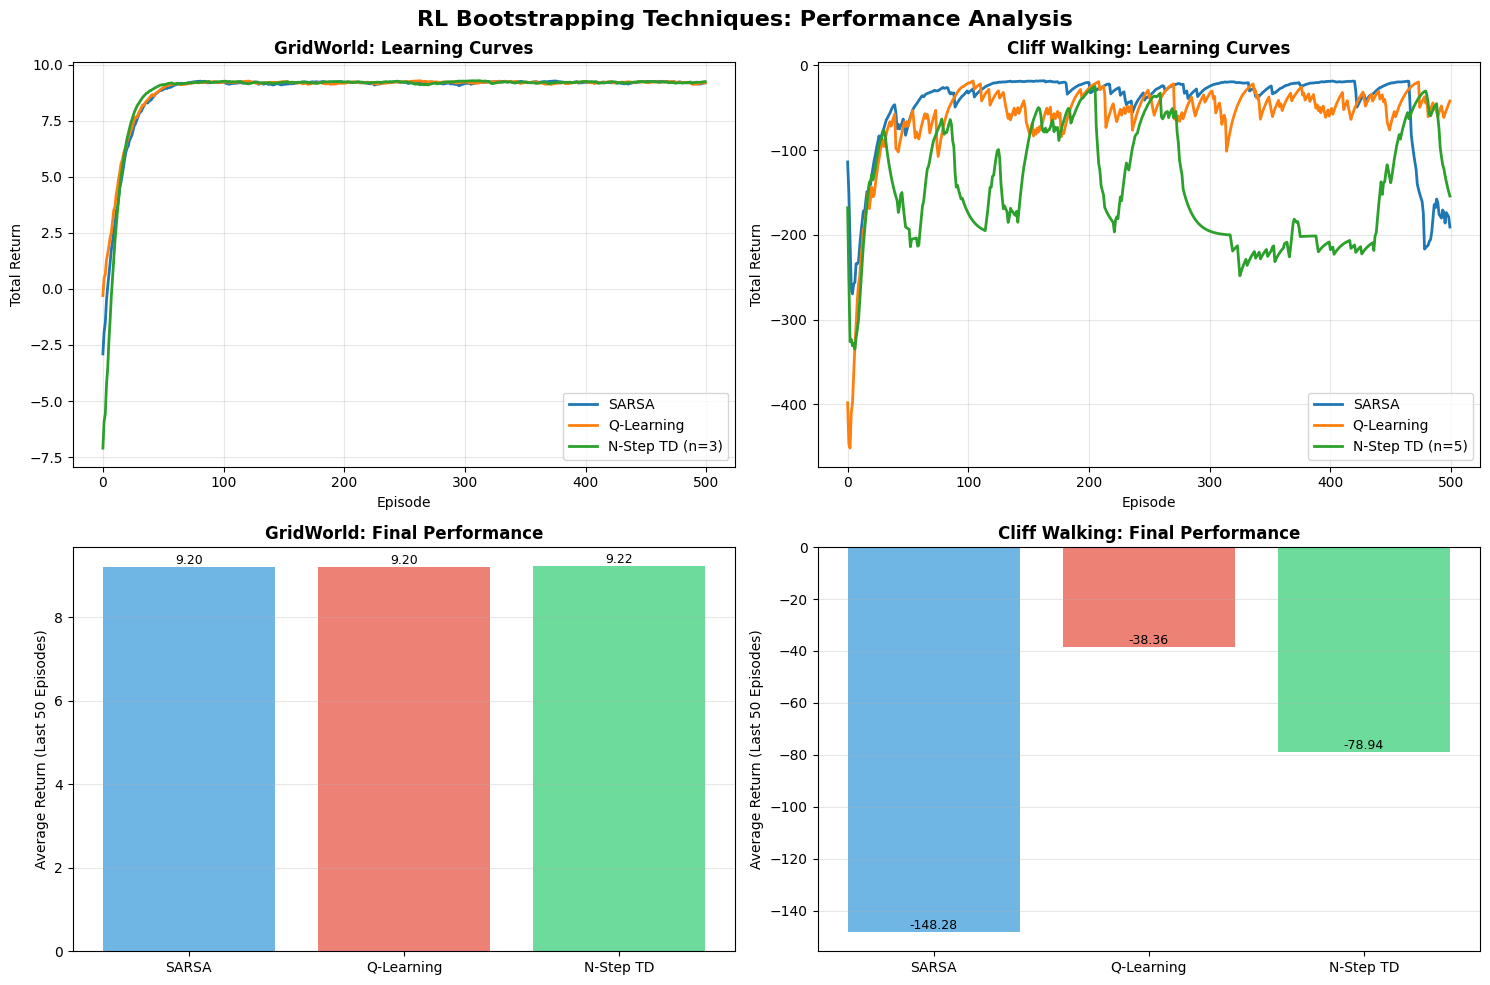


ANALYSIS RESULTS

[GridWorld Environment]
  SARSA         - Final Avg: 9.20
  Q-Learning    - Final Avg: 9.20
  N-Step TD(3)  - Final Avg: 9.22

[Cliff Walking Environment]
  SARSA         - Final Avg: -148.28
  Q-Learning    - Final Avg: -38.36
  N-Step TD(5)  - Final Avg: -78.94

KEY OBSERVATIONS

1. SARSA (On-Policy):
   - More conservative, learns safer policies
   - Better in Cliff Walking (avoids risky cliff edges)
   - Stable learning curve

2. Q-Learning (Off-Policy):
   - More aggressive, learns optimal policy
   - May take risky paths initially
   - Faster convergence in some cases

3. N-Step TD:
   - Balances between TD and Monte Carlo
   - Better credit assignment with n-step returns
   - Performance depends on choice of n

4. Environment Impact:
   - GridWorld: All methods perform similarly
   - Cliff Walking: SARSA safer than Q-Learning
   - Algorithm choice matters based on environment
    


In [8]:
# This will train all agents on both environments and show the results.
run_experiments()